<a href="https://colab.research.google.com/github/YoursTruly-02/Robust-Phishing-and-Homoglyph-Detection-Engine/blob/main/Robust_Phishing_and_Homoglyph_Detection_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dhrubangtalukdar/real-world-phishing-url-classification-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'real-world-phishing-url-classification-data' dataset.
Path to dataset files: /kaggle/input/real-world-phishing-url-classification-data


In [2]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from urllib.parse import urlparse
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

Finding file and Loading dataset

In [3]:
files = os.listdir(path)
print("Files in downloaded folder:", files)


csv_filename = [f for f in files if f.endswith('.csv')][0]
full_file_path = os.path.join(path, csv_filename)


df = pd.read_csv(full_file_path)

df.head()

Files in downloaded folder: ['phishing_url_dataset_unique.csv']


,url,label,source
0,http://110.37.26.193:54956/bin.sh,1,urlhaus
1,https://sentry5.obor1shwron8.ru/4ylkytvt,1,urlhaus
2,https://d6gu.ripple-cask.ru/jid43vpd,1,urlhaus
3,http://130.12.180.34/596a96cc7bf9108cd896f33c4...,1,urlhaus
4,https://bronze.systems,0,tranco


**overview**

In [4]:
df.info()
df['source'].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48812 entries, 0 to 48811
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   url     48812 non-null  object
 1   label   48812 non-null  int64 
 2   source  48812 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.1+ MB


array(['urlhaus', 'tranco', 'openphish'], dtype=object)

/tmp/ipykernel_48578/303655582.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="label", data=df, palette="Set2")


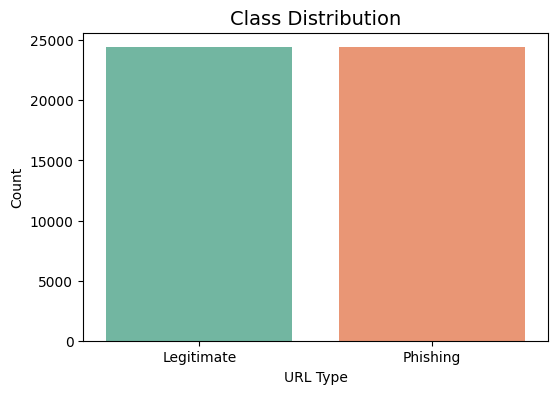

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x="label", data=df, palette="Set2")
plt.xticks([0,1], ["Legitimate", "Phishing"])
plt.title("Class Distribution", fontsize=14)
plt.xlabel("URL Type")
plt.ylabel("Count")
plt.show()

**Feature engineering**

In [6]:
def extract_features(url):
    features = {}
    features["url_length"] = len(url)
    features["digit_count"] = sum(c.isdigit() for c in url)
    features["special_char_count"] = len(re.findall(r"[-@_.?=#]", url))
    features["has_https"] = 1 if url.startswith("https") else 0
    features["has_ip"] = 1 if re.search(r"\d+\.\d+\.\d+\.\d+", url) else 0
    return pd.Series(features)

url_features = df["url"].apply(extract_features)
df_features = pd.concat([df, url_features], axis=1)

df_features.head()

,url,label,source,url_length,digit_count,special_char_count,has_https,has_ip
0,http://110.37.26.193:54956/bin.sh,1,urlhaus,33,15,4,0,1
1,https://sentry5.obor1shwron8.ru/4ylkytvt,1,urlhaus,40,4,2,1,0
2,https://d6gu.ripple-cask.ru/jid43vpd,1,urlhaus,36,3,3,1,0
3,http://130.12.180.34/596a96cc7bf9108cd896f33c4...,1,urlhaus,91,46,4,0,1
4,https://bronze.systems,0,tranco,22,0,1,1,0


/tmp/ipykernel_48578/181218346.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


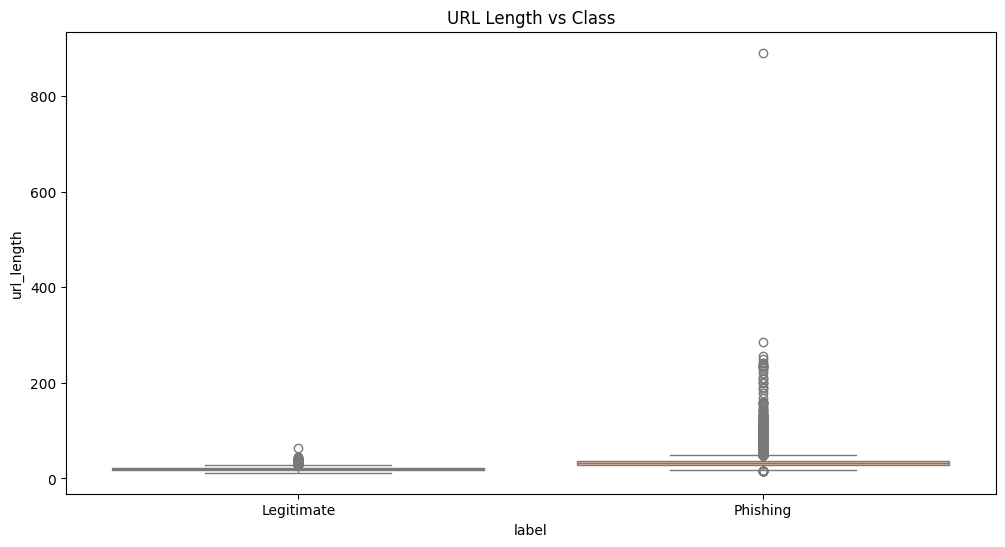

In [7]:
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df_features,
    x="label",
    y="url_length",
    palette="coolwarm"
)
plt.xticks([0,1], ["Legitimate", "Phishing"])
plt.title("URL Length vs Class")
plt.show()

**TF IDF vectorization of url**

In [8]:
tfidf = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3,5),
    max_features=5000
)

X_text = tfidf.fit_transform(df["url"]).toarray() #changes
df_X_text = pd.DataFrame(X_text)

df_X_text.head()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
X_combined = pd.concat([df_X_text.reset_index(drop=True), url_features.reset_index(drop=True)], axis=1)

In [10]:
X_combined.head()

,0,1,2,3,4,5,6,7,8,9,...,4995,4996,4997,4998,4999,url_length,digit_count,special_char_count,has_https,has_ip
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,33,15,4,0,1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,40,4,2,1,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,36,3,3,1,0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,91,46,4,0,1
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,22,0,1,1,0


**train test split**

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_combined,
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

**model1** **LR**

In [12]:

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, y_prob_lr))
accuracy_score(y_test,y_pred_lr)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4882
           1       1.00      1.00      1.00      4881

    accuracy                           1.00      9763
   macro avg       1.00      1.00      1.00      9763
weighted avg       1.00      1.00      1.00      9763

ROC AUC: 0.9996472791478567


0.9974393116869814

**model2** **rf**

In [13]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))
accuracy_score(y_test,y_pred_rf)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4882
           1       1.00      1.00      1.00      4881

    accuracy                           1.00      9763
   macro avg       1.00      1.00      1.00      9763
weighted avg       1.00      1.00      1.00      9763

ROC AUC: 0.9995202492823673


0.9979514493495851

**confusion** **mat** **rf**

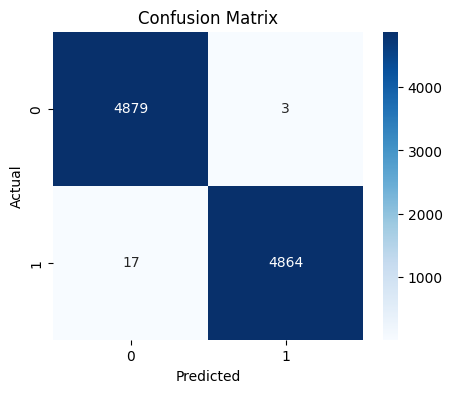

In [14]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**model3 XGB**

In [15]:
xgboost = XGBClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

xgboost.fit(X_train, y_train)

y_pred_xgb = xgboost.predict(X_test)
y_prob_xgb = xgboost.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_prob_xgb))
accuracy_score(y_test,y_pred_xgb)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4882
           1       1.00      1.00      1.00      4881

    accuracy                           1.00      9763
   macro avg       1.00      1.00      1.00      9763
weighted avg       1.00      1.00      1.00      9763

ROC AUC: 0.9995788962057308


0.9982587319471474

**confusion mat xgb**

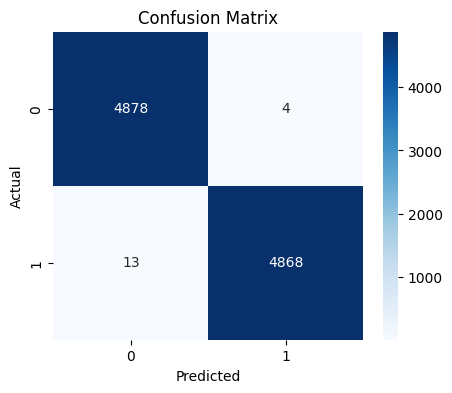

In [16]:
cm2=confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5,4))
sns.heatmap(cm2, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**model** **saving**

In [17]:
xgboost.save_model('phishing_model_native.json')

In [18]:
import pickle

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)